In [1]:
# Cell 1: Import libraries and load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset using the exact file name provided
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("✅ Successfully loaded Mall_Customers.csv")
except FileNotFoundError:
    print("🚨 ERROR: Could not find 'Mall_Customers.csv'. Please ensure it is in the same folder as this notebook.")

# Data Cleaning
# 1. Strip invisible spaces from column names to prevent KeyErrors
df.columns = df.columns.str.strip()

# 2. Drop CustomerID as it has no behavioral value for clustering
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

# Display the clean data
print("\nCleaned Dataset Info:")
df.info()
display(df.head())

✅ Successfully loaded Mall_Customers.csv

Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


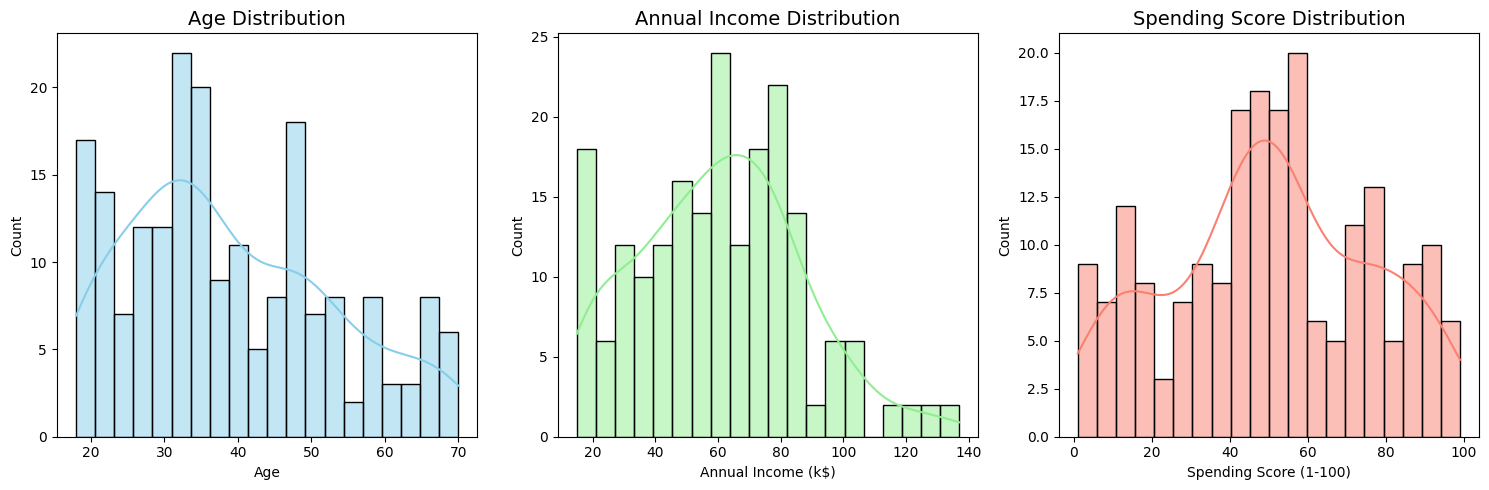

In [2]:
# Cell 2: EDA - Distribution of key metrics
plt.figure(figsize=(15, 5))

# Plot Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue', bins=20)
plt.title('Age Distribution', fontsize=14)

# Plot Income Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], kde=True, color='lightgreen', bins=20)
plt.title('Annual Income Distribution', fontsize=14)

# Plot Spending Score Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='salmon', bins=20)
plt.title('Spending Score Distribution', fontsize=14)

plt.tight_layout()
plt.show()

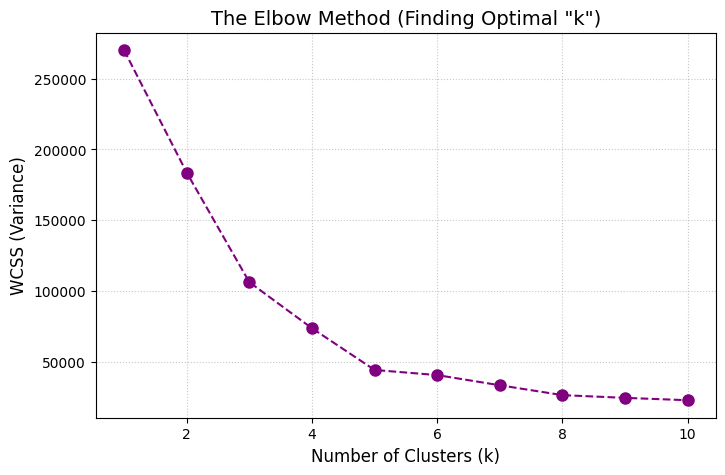

In [3]:
# Cell 3: Finding the optimal number of clusters
from sklearn.cluster import KMeans

# We will focus our clustering purely on behavioral metrics: Income and Spending
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = [] # Within-Cluster Sum of Squares

# Test algorithms grouping the data into 1 to 10 clusters
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple', markersize=8)
plt.title('The Elbow Method (Finding Optimal "k")', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Variance)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

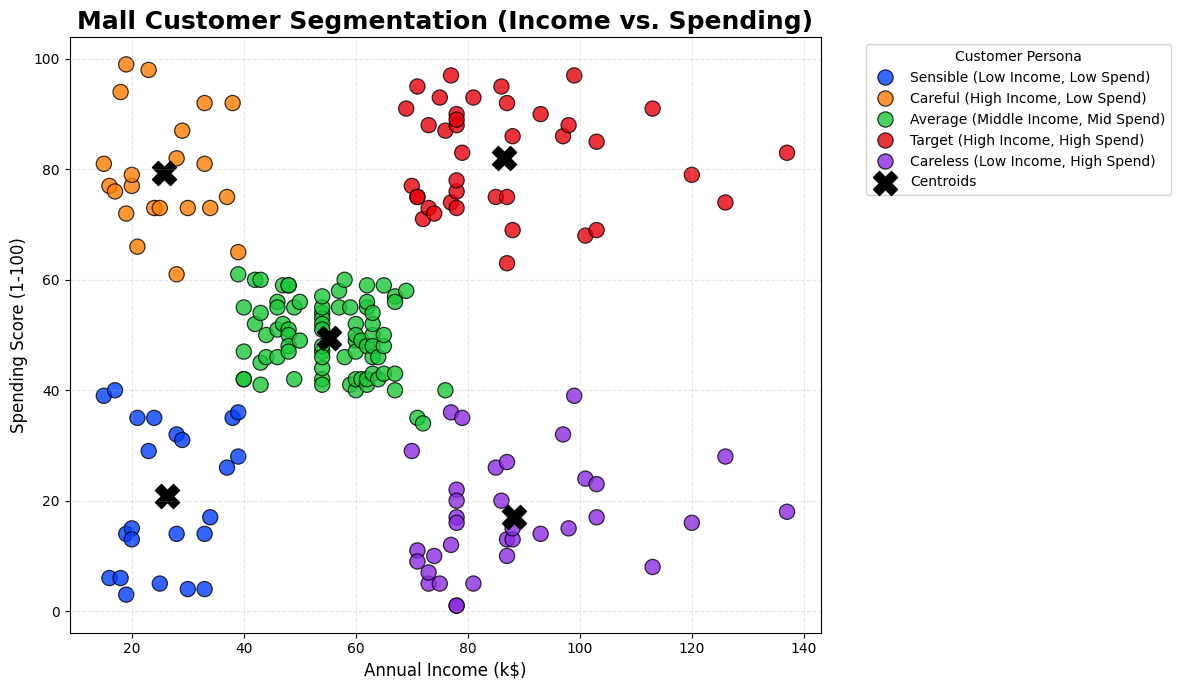

In [4]:
# Cell 4: Applying K-Means and Visualizing Segments
# Train the final model with the optimal k=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Customer_Persona'] = kmeans.fit_predict(X)

# Name the clusters for our business report based on their math coordinates
cluster_names = {
    0: 'Average (Middle Income, Mid Spend)',
    1: 'Target (High Income, High Spend)',
    2: 'Careful (High Income, Low Spend)',
    3: 'Careless (Low Income, High Spend)',
    4: 'Sensible (Low Income, Low Spend)'
}
df['Persona_Name'] = df['Customer_Persona'].map(cluster_names)

# Visualize the 5 customer segments
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Persona_Name', 
    palette='bright', 
    s=120, 
    alpha=0.8,
    edgecolor='black'
)

# Plot the centroids (the exact mathematical center of each group)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title('Mall Customer Segmentation (Income vs. Spending)', fontsize=18, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Customer Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Business Insights & Segmentation Report

By deploying the K-Means clustering algorithm, we successfully identified **5 distinct customer personas** within the mall's demographic data.

### Customer Personas Identified:
1. **The Target Group (High Income, High Spend):** These are the most lucrative customers. The marketing team should aggressively target this group with loyalty programs, VIP events, and premium product launches to maintain their high engagement.
2. **The Careful Group (High Income, Low Spend):** This group has deep pockets but is highly resistant to spending. Market research is required to find out what they value (e.g., higher quality, better customer service, exclusive discounts) to convert their income into sales.
3. **The Careless Group (Low Income, High Spend):** These customers spend heavily despite lower earnings. While they generate revenue, the business should market to them ethically, perhaps focusing on sales, discounts, and high-value bundle deals.
4. **The Sensible Group (Low Income, Low Spend):** This segment spends strictly within their means. Focus on necessity-driven marketing and budget-friendly promotions to capture their steady, reliable business.
5. **The Average Group (Middle Income, Middle Spend):** The largest cluster, representing the standard mall-goer. Standard seasonal marketing and general promotions are highly effective here.